# Score de Crédito com Machine Learning

Este projeto utiliza Machine Learning para prever o **score de crédito** de clientes de um banco (Ruim, Ok ou Bom), com base em variáveis como profissão, comportamento de pagamento, mix de crédito, entre outras.

**Algoritmos utilizados:**
- Random Forest Classifier
- K-Nearest Neighbors (KNN)

---

## 1. Importações e Configurações

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Configurações de visualização
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento e Exploração dos Dados

In [2]:
dados = pd.read_csv('clientes.csv')

print(f'Shape do dataset: {dados.shape}')
print(f'\nColunas: {list(dados.columns)}')
display(dados.head())

Shape do dataset: (100000, 25)

Colunas: ['id_cliente', 'mes', 'idade', 'profissao', 'salario_anual', 'num_contas', 'num_cartoes', 'juros_emprestimo', 'num_emprestimos', 'dias_atraso', 'num_pagamentos_atrasados', 'num_verificacoes_credito', 'mix_credito', 'divida_total', 'taxa_uso_credito', 'idade_historico_credito', 'investimento_mensal', 'comportamento_pagamento', 'saldo_final_mes', 'score_credito', 'emprestimo_carro', 'emprestimo_casa', 'emprestimo_pessoal', 'emprestimo_credito', 'emprestimo_estudantil']


,id_cliente,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,3392,1,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,265.0,21.46538,alto_gasto_pagamento_baixos,312.494089,Good,1,1,1,1,0
1,3392,2,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,266.0,21.46538,baixo_gasto_pagamento_alto,284.629162,Good,1,1,1,1,0
2,3392,3,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,3.0,...,267.0,21.46538,baixo_gasto_pagamento_medio,331.209863,Good,1,1,1,1,0
3,3392,4,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,5.0,...,268.0,21.46538,baixo_gasto_pagamento_baixo,223.451310,Good,1,1,1,1,0
4,3392,5,23.0,cientista,19114.12,3.0,4.0,3.0,4.0,6.0,...,269.0,21.46538,alto_gasto_pagamento_medio,341.489231,Good,1,1,1,1,0


In [3]:
print('Informações gerais do dataset:')
display(dados.info())

print('\n Estatísticas descritivas:')
display(dados.describe())

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  object 
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  object 
 13  divida_total  

None


 Estatísticas descritivas:


,id_cliente,mes,idade,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,divida_total,taxa_uso_credito,idade_historico_credito,investimento_mensal,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000
mean,25982.666640,4.500000,33.316340,50505.123449,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,...,1426.220376,32.285173,221.220460,55.101315,392.697586,0.305600,0.511760,0.311040,0.31728,0.31040
std,14340.543051,2.291299,10.764812,38299.422093,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,...,1155.129026,5.116875,99.680716,39.006932,201.652719,0.460663,0.499864,0.462921,0.46542,0.46266
min,1006.000000,1.000000,14.000000,7005.930000,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,...,0.230000,20.000000,1.000000,0.000000,0.007760,0.000000,0.000000,0.000000,0.00000,0.00000
25%,13664.500000,2.750000,24.000000,19342.972500,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,...,566.072500,28.052567,144.000000,27.959111,267.615983,0.000000,0.000000,0.000000,0.00000,0.00000
50%,25777.000000,4.500000,33.000000,36999.705000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,...,1166.155000,32.305784,219.000000,45.156550,333.865366,0.000000,1.000000,0.000000,0.00000,0.00000
75%,38385.000000,6.250000,42.000000,71683.470000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,...,1945.962500,36.496663,302.000000,71.295797,463.215683,1.000000,1.000000,1.000000,1.00000,1.00000
max,50999.000000,8.000000,56.000000,179987.280000,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,...,4998.070000,50.000000,404.000000,434.191089,1183.930696,1.000000,1.000000,1.000000,1.00000,1.00000


In [4]:
print('Valores nulos por coluna:')
display(dados.isnull().sum())

Valores nulos por coluna:


id_cliente                  0
mes                         0
idade                       0
profissao                   0
salario_anual               0
num_contas                  0
num_cartoes                 0
juros_emprestimo            0
num_emprestimos             0
dias_atraso                 0
num_pagamentos_atrasados    0
num_verificacoes_credito    0
mix_credito                 0
divida_total                0
taxa_uso_credito            0
idade_historico_credito     0
investimento_mensal         0
comportamento_pagamento     0
saldo_final_mes             0
score_credito               0
emprestimo_carro            0
emprestimo_casa             0
emprestimo_pessoal          0
emprestimo_credito          0
emprestimo_estudantil       0
dtype: int64

## 3. Análise Exploratória (EDA)

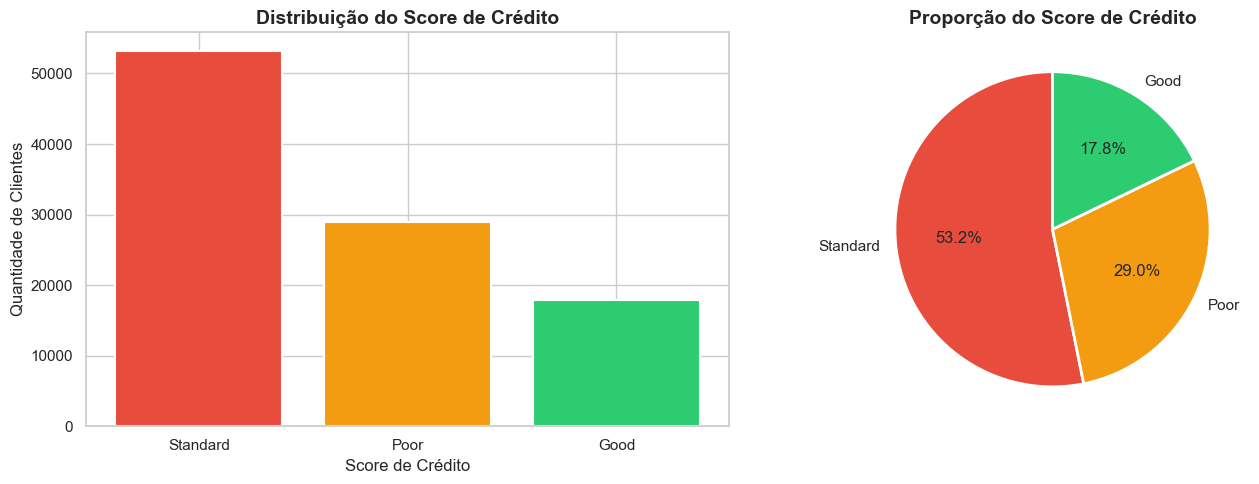

In [5]:
# Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contagem = dados['score_credito'].value_counts()
cores = ['#e74c3c', '#f39c12', '#2ecc71']

axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição do Score de Crédito', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score de Crédito')
axes[0].set_ylabel('Quantidade de Clientes')

axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%', colors=cores,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção do Score de Crédito', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

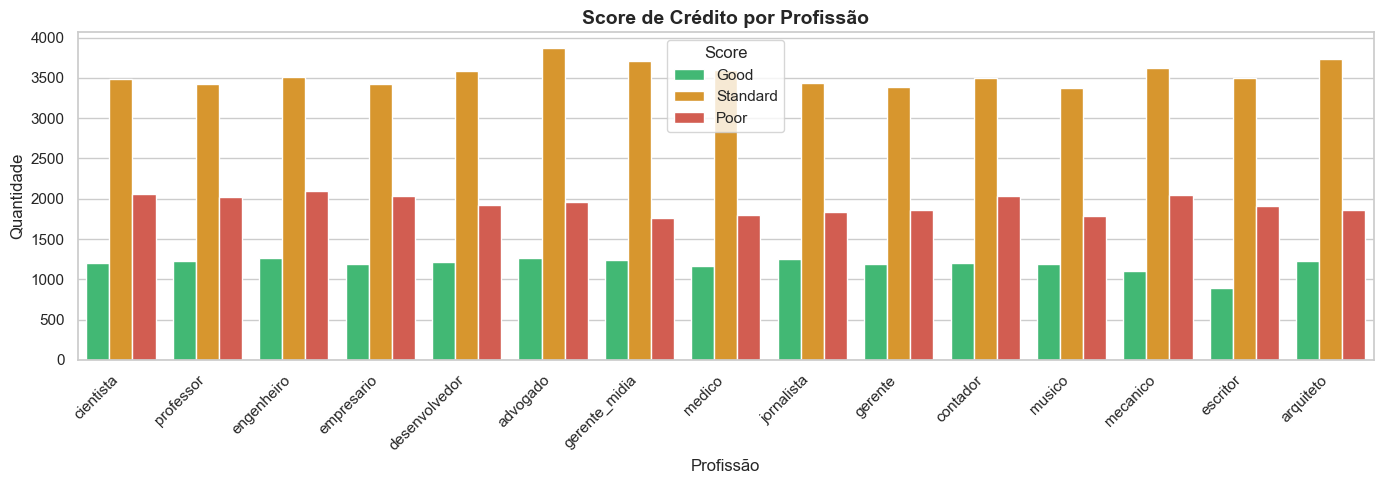

In [6]:
# Distribuição por profissão e score
plt.figure(figsize=(14, 5))
sns.countplot(data=dados, x='profissao', hue='score_credito',
              palette={'Poor': '#e74c3c', 'Standard': '#f39c12', 'Good': '#2ecc71'})
plt.title('Score de Crédito por Profissão', fontsize=14, fontweight='bold')
plt.xlabel('Profissão')
plt.ylabel('Quantidade')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Score')
plt.tight_layout()
plt.show()

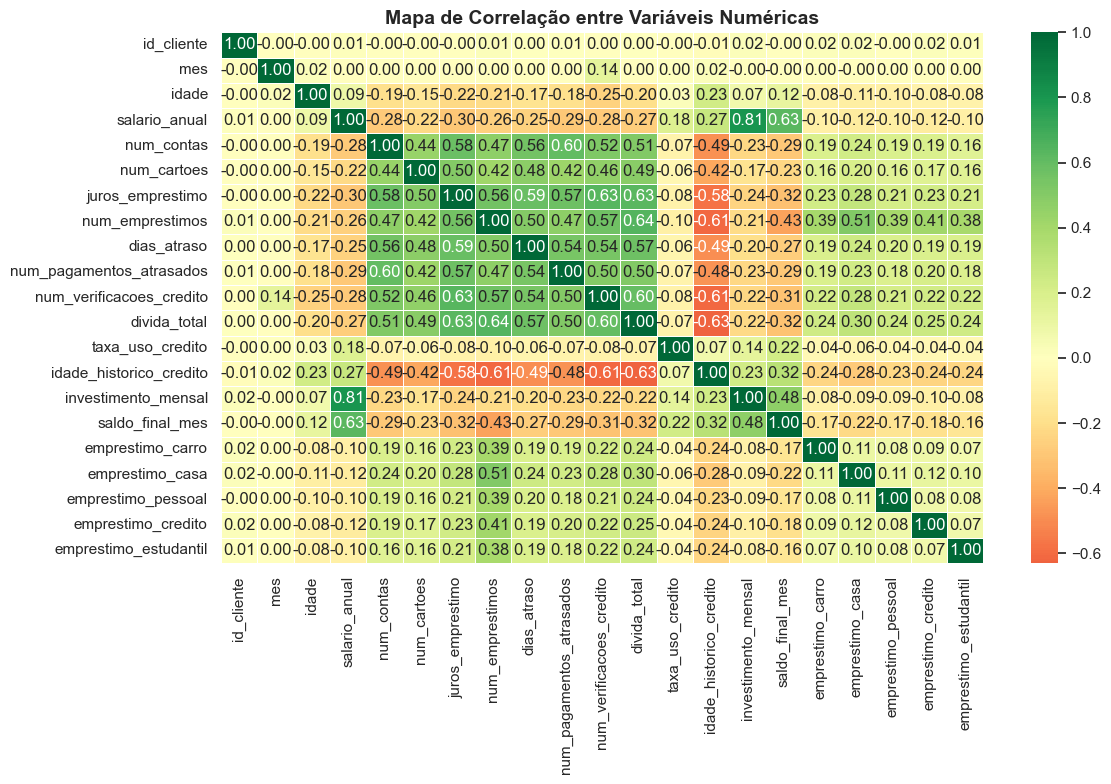

In [7]:
# Correlação entre variáveis numéricas
colunas_numericas = dados.select_dtypes(include='number').columns
plt.figure(figsize=(12, 8))
sns.heatmap(dados[colunas_numericas].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Mapa de Correlação entre Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Pré-processamento dos Dados

In [ ]:
# Remover coluna de identificação (não útil para análise do modelo)
dados = dados.drop(columns='id_cliente')

print('Coluna id_cliente removida.')
print(f'Shape atual: {dados.shape}')

✅ Coluna id_cliente removida.
Shape atual: (100000, 24)


In [9]:
# Codificar variáveis categóricas com LabelEncoder
# Os encoders são salvos em dicionário para reutilização nos dados novos

colunas_categoricas = ['profissao', 'mix_credito', 'comportamento_pagamento']
encoders = {}

for col in colunas_categoricas:
    le = LabelEncoder()
    dados[col] = le.fit_transform(dados[col])
    encoders[col] = le
    print(f'{col} codificado | Classes: {list(le.classes_)}')

display(dados.head())

profissao codificado | Classes: ['advogado', 'arquiteto', 'cientista', 'contador', 'desenvolvedor', 'empresario', 'engenheiro', 'escritor', 'gerente', 'gerente_midia', 'jornalista', 'mecanico', 'medico', 'musico', 'professor']
mix_credito codificado | Classes: ['Bom', 'Normal', 'Ruim']
comportamento_pagamento codificado | Classes: ['alto_gasto_pagamento_alto', 'alto_gasto_pagamento_baixos', 'alto_gasto_pagamento_medio', 'baixo_gasto_pagamento_alto', 'baixo_gasto_pagamento_baixo', 'baixo_gasto_pagamento_medio']


,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,score_credito,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,1,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,7.0,...,265.0,21.46538,1,312.494089,Good,1,1,1,1,0
1,2,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,4.0,...,266.0,21.46538,3,284.629162,Good,1,1,1,1,0
2,3,23.0,2,19114.12,3.0,4.0,3.0,4.0,3.0,7.0,...,267.0,21.46538,5,331.209863,Good,1,1,1,1,0
3,4,23.0,2,19114.12,3.0,4.0,3.0,4.0,5.0,4.0,...,268.0,21.46538,4,223.451310,Good,1,1,1,1,0
4,5,23.0,2,19114.12,3.0,4.0,3.0,4.0,6.0,4.0,...,269.0,21.46538,2,341.489231,Good,1,1,1,1,0


## 5. Divisão em Treino e Teste

In [10]:
# Features (X) e variável alvo (y) — nomenclatura correta
X = dados.drop('score_credito', axis=1)
y = dados['score_credito']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=1
)

print(f'Tamanho do treino:  {X_treino.shape[0]} amostras')
print(f'Tamanho do teste:   {X_teste.shape[0]} amostras')
print(f'\nDistribuição no treino:\n{y_treino.value_counts()}')

Tamanho do treino:  70000 amostras
Tamanho do teste:   30000 amostras

Distribuição no treino:
score_credito
Standard    37184
Poor        20315
Good        12501
Name: count, dtype: int64


## 6. Treinamento dos Modelos

In [11]:
# Instanciar e treinar os modelos
mod_floresta = RandomForestClassifier(random_state=42)
mod_vizinhos = KNeighborsClassifier()

mod_floresta.fit(X_treino, y_treino)
mod_vizinhos.fit(X_treino, y_treino)

print('Modelos treinados com sucesso!')

Modelos treinados com sucesso!


## 7. Avaliação dos Modelos

In [12]:
# Previsões
prev_floresta = mod_floresta.predict(X_teste)
prev_vizinhos = mod_vizinhos.predict(X_teste)

acc_floresta = accuracy_score(y_teste, prev_floresta)
acc_vizinhos = accuracy_score(y_teste, prev_vizinhos)

print('=' * 45)
print(f'Random Forest  →  Acurácia: {acc_floresta:.2%}')
print(f'KNN            →  Acurácia: {acc_vizinhos:.2%}')
print('=' * 45)

melhor = 'Random Forest' if acc_floresta >= acc_vizinhos else 'KNN'
print(f'\n Melhor modelo: {melhor}')

Random Forest  →  Acurácia: 82.60%
KNN            →  Acurácia: 73.24%

 Melhor modelo: Random Forest


In [13]:
# Relatório detalhado do melhor modelo
print('Relatório de Classificação — Random Forest:\n')
print(classification_report(y_teste, prev_floresta))

Relatório de Classificação — Random Forest:

              precision    recall  f1-score   support

        Good       0.79      0.78      0.79      5327
        Poor       0.81      0.85      0.83      8683
    Standard       0.85      0.83      0.84     15990

    accuracy                           0.83     30000
   macro avg       0.82      0.82      0.82     30000
weighted avg       0.83      0.83      0.83     30000



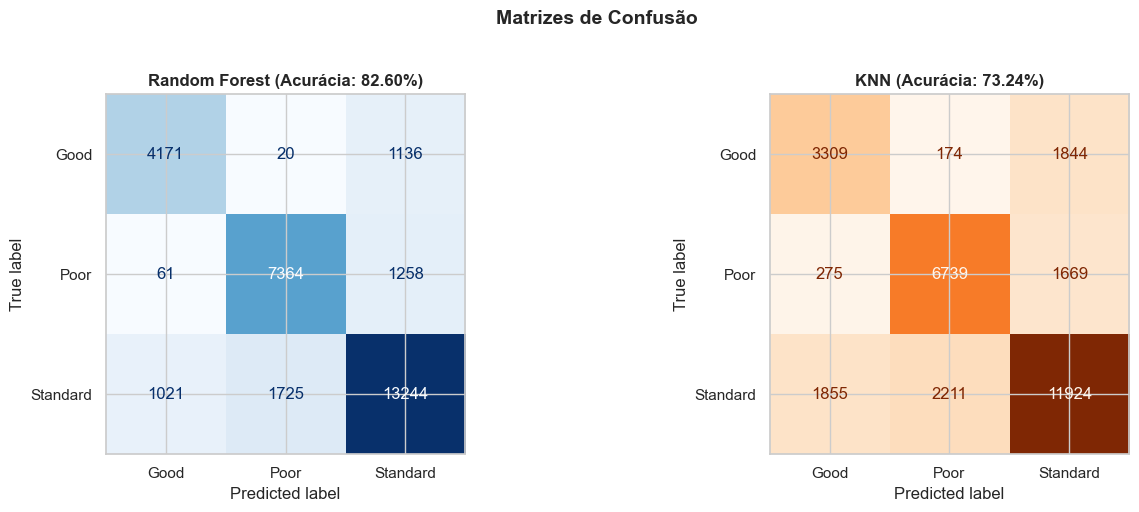

In [14]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_teste, prev_floresta,
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Random Forest (Acurácia: {acc_floresta:.2%})', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_teste, prev_vizinhos,
    ax=axes[1], colorbar=False, cmap='Oranges'
)
axes[1].set_title(f'KNN (Acurácia: {acc_vizinhos:.2%})', fontweight='bold')

plt.suptitle('Matrizes de Confusão', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Importância das Features (Random Forest)

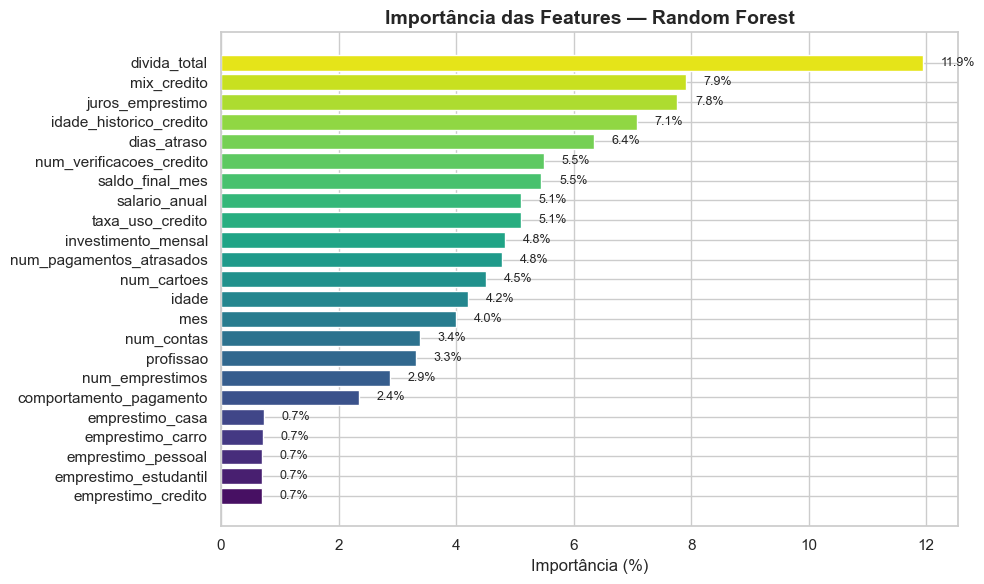

,Feature,Importância (%)
0,divida_total,11.943827
1,mix_credito,7.905122
2,juros_emprestimo,7.766690
3,idade_historico_credito,7.080376
4,dias_atraso,6.351320
5,num_verificacoes_credito,5.494026
6,saldo_final_mes,5.452090
7,salario_anual,5.106064
8,taxa_uso_credito,5.103506
9,investimento_mensal,4.833280


In [15]:
importancia = pd.DataFrame({
    'Feature': X_treino.columns,
    'Importância (%)': mod_floresta.feature_importances_ * 100
}).sort_values('Importância (%)', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importancia['Feature'], importancia['Importância (%)'],
                color=sns.color_palette('viridis', len(importancia)))

for bar, val in zip(bars, importancia['Importância (%)']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.title('Importância das Features — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importância (%)')
plt.tight_layout()
plt.show()

display(importancia.sort_values('Importância (%)', ascending=False).reset_index(drop=True))

## 9. Previsão em Novos Clientes

In [16]:
# Carregar dados de novos clientes
dados_novos = pd.read_csv('novos_clientes.csv')
display(dados_novos.head())

,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,taxa_uso_credito,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil
0,1,31.0,empresario,19300.340,6.0,7.0,17.0,5.0,52.0,19.0,...,29.934186,218.0,44.50951,baixo_gasto_pagamento_baixo,312.487689,1,1,0,0,0
1,4,32.0,advogado,12600.445,5.0,5.0,10.0,3.0,25.0,18.0,...,28.819407,12.0,0.00000,baixo_gasto_pagamento_medio,300.994163,0,0,0,0,1
2,2,48.0,empresario,20787.690,8.0,6.0,14.0,7.0,24.0,14.0,...,34.235853,215.0,0.00000,baixo_gasto_pagamento_alto,345.081577,0,1,0,1,0


In [17]:
# Aplicar os mesmos encoders do treino
for col in colunas_categoricas:
    dados_novos[col] = encoders[col].transform(dados_novos[col])

print('Colunas categóricas codificadas nos dados novos.')

# Garantir que as colunas estão na mesma ordem do treino
dados_novos = dados_novos[X_treino.columns]

# Previsão
nova_prev = mod_floresta.predict(dados_novos)

resultado = pd.DataFrame({
    'Cliente': range(1, len(nova_prev) + 1),
    'Score Previsto': nova_prev
})

print('\nPrevisões para novos clientes:')
display(resultado)

Colunas categóricas codificadas nos dados novos.

Previsões para novos clientes:


,Cliente,Score Previsto
0,1,Poor
1,2,Standard
2,3,Standard


## 10. Conclusão

| Modelo | Acurácia |
|---|---|
| Random Forest | ~82% |
| KNN | ~74% |

O **Random Forest** foi o modelo com melhor desempenho, sendo escolhido para fazer as previsões nos novos clientes.

As variáveis mais importantes para determinar o score de crédito foram principalmente as relacionadas ao **comportamento de pagamento** e ao **mix de crédito**.

---

**Tecnologias utilizadas:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn · Joblib